# What Does It Mean for Synthetic Data to Be Indistinguishable from Real Data?

A research-style experimental pipeline built on the `rfhack` codebase.  
Each section is self-contained: compute first, then plot.

---

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker

from rfhack.core.loaders import load_HIV, load_breast, load_diabetes
from rfhack.core.rf_wrapper import RFWrapper
from rfhack.core.metrics import stratified_subsample, tstr_f1

# ── shared config ──────────────────────────────────────────────────────────────
TARGET_AUC   = 0.7
SEED         = 42
FRACTIONS    = [0.2, 0.3, 0.4, 0.5]
LOADERS      = {"HIV": load_HIV, "Breast Cancer": load_breast, "Diabetes": load_diabetes}

METHOD_COLORS = {
    "bootstrap": "#4878CF",
    "iid":       "#9467BD",
    "gmm":       "#F28E2B",
    "cvae":      "#59A14F",
}


---
## Section 7 — Hack Baseline

**Question:** Is there such a thing as too much noise?

**Setup** (mirrors `convince.py`):
- For each dataset × fraction, run `AdversarialHacker.hack()` fresh — no CSV
- Then fix σ at several levels and repeat the RF discriminator evaluation N times
- Plot the distribution of AUC scores per σ level

**Intuition:**
- At σ=0: synthetic = raw bootstrap copy of real → barely distinguishable → AUC ≈ 0.5
- As σ increases: synthetic diverges from real → RF detects it more easily → AUC rises
- `hack_sigma` = the σ where AUC ≈ 0.55 (just barely detectable)
- At very high σ: synthetic is pure noise → AUC → 1.0 — *this is "too much noise"*

Adding noise **increases** AUC. The hack finds where to **stop**.

In [2]:
# ── Step 1: run AdversarialHacker fresh per dataset × fraction ────────────────
# No CSV — mirrors calibration.py's run_hack()

from rfhack import AdversarialHacker

hack_results = {}   # key: (ds_name, frac) → AdversarialResult

for ds_name, loader in LOADERS.items():
    data = loader()
    X, y = data["X"], data["y"]

    n0_full = int((y == 0).sum())
    n1_full = int((y == 1).sum())

    for frac in FRACTIONS:
        n0 = max(2, int(n0_full * frac))
        n1 = max(2, int(n1_full * frac))
        X_sub, y_sub, _ = stratified_subsample(X, y, n0=n0, n1=n1, seed=SEED)

        df_sub = pd.DataFrame(X_sub, columns=[f"f{i}" for i in range(X_sub.shape[1])])
        hacker = AdversarialHacker(df_sub)
        result = hacker.hack(TARGET_AUC)
        hack_results[(ds_name, frac)] = result

        converged = abs(result.auc - TARGET_AUC) < hacker.tol
        print(f"{ds_name:<15} frac={frac}  sigma={result.sigma:.4f}  "
              f"AUC={result.auc:.3f}  {'OK' if converged else 'NOT CONVERGED'}")

print("\nDone.")

c:\Users\tonyt\Desktop\rfhack\.venv\Lib\site-packages\sklearn\preprocessing\_label.py:120: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)


HIV             frac=0.2  sigma=0.7422  AUC=0.697  OK
HIV             frac=0.3  sigma=0.4199  AUC=0.705  OK
HIV             frac=0.4  sigma=0.2460  AUC=0.733  NOT CONVERGED
HIV             frac=0.5  sigma=0.1817  AUC=0.703  OK
Breast Cancer   frac=0.2  sigma=0.4785  AUC=0.695  NOT CONVERGED
Breast Cancer   frac=0.3  sigma=0.3600  AUC=0.706  NOT CONVERGED
Breast Cancer   frac=0.4  sigma=0.3223  AUC=0.691  NOT CONVERGED
Breast Cancer   frac=0.5  sigma=0.2504  AUC=0.693  NOT CONVERGED
Diabetes        frac=0.2  sigma=0.0026  AUC=0.698  OK
Diabetes        frac=0.3  sigma=0.0012  AUC=0.824  NOT CONVERGED
Diabetes        frac=0.4  sigma=0.0002  AUC=0.819  NOT CONVERGED
Diabetes        frac=0.5  sigma=0.0195  AUC=0.860  NOT CONVERGED

Done.


In [3]:
# ── Step 2: fixed-sigma repeated RF evaluation ────────────────────────────────
# For each dataset, pick one fraction (0.3) and test a range of fixed sigma levels.
# At each sigma: draw N independent bootstrap+noise samples, score RF each time.
# This shows AUC distribution at each sigma — is there variance? Is it monotone?

from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import roc_auc_score

N_REPEATS  = 10
TEST_FRAC  = 0.3
EVAL_FRAC  = 0.3   # which fraction to use for this experiment
PROBE_SIGMAS = [0.0, 0.05, 0.1, 0.2, 0.3, 0.5, 0.75, 1.0, 1.5, 2.0]

def repeated_rf_at_sigma(X_sub, sigma, n_repeats=N_REPEATS, seed=SEED):
    """
    Mirrors convince.py exactly:
      - build real vs noisy-bootstrap combined dataset
      - run N independent train/test splits
      - return list of AUC scores
    """
    rng   = np.random.default_rng(seed)
    n     = len(X_sub)
    stds  = X_sub.std(axis=0)
    stds  = np.where(stds == 0, 1.0, stds)
    feat_cols = [f"f{i}" for i in range(X_sub.shape[1])]

    aucs = []
    for i in range(n_repeats):
        # fresh bootstrap + noise draw each repeat
        idx    = rng.integers(0, n, size=n)
        X_boot = X_sub[idx].astype(np.float64)
        noise  = rng.standard_normal(X_boot.shape) * stds * sigma
        X_syn  = X_boot + noise

        real_df          = pd.DataFrame(X_sub.astype(np.float64), columns=feat_cols)
        real_df["target"] = 1
        syn_df           = pd.DataFrame(X_syn, columns=feat_cols)
        syn_df["target"]  = 0
        combined         = pd.concat([real_df, syn_df], ignore_index=True)

        X_c = combined.drop(columns=["target"]).values
        y_c = combined["target"].values

        X_tr, X_te, y_tr, y_te = train_test_split(
            X_c, y_c, test_size=TEST_FRAC, stratify=y_c, random_state=i
        )
        clf = RandomForestClassifier(n_estimators=100, random_state=i)
        clf.fit(X_tr, y_tr)
        probs = clf.predict_proba(X_te)[:, 1]
        aucs.append(roc_auc_score(y_te, probs))

    return aucs


sigma_auc_data = {}   # key: (ds_name) → dict of sigma → [auc list]

for ds_name, loader in LOADERS.items():
    data = loader()
    X, y = data["X"], data["y"]

    n0 = max(2, int((y == 0).sum() * EVAL_FRAC))
    n1 = max(2, int((y == 1).sum() * EVAL_FRAC))
    X_sub, _, _ = stratified_subsample(X, y, n0=n0, n1=n1, seed=SEED)

    sigma_auc_data[ds_name] = {}
    for sigma in PROBE_SIGMAS:
        aucs = repeated_rf_at_sigma(X_sub, sigma)
        sigma_auc_data[ds_name][sigma] = aucs
        print(f"{ds_name:<15} sigma={sigma:.2f}  "
              f"mean={np.mean(aucs):.3f}  min={np.min(aucs):.3f}  max={np.max(aucs):.3f}")

print("\nDone.")

c:\Users\tonyt\Desktop\rfhack\.venv\Lib\site-packages\sklearn\preprocessing\_label.py:120: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)


HIV             sigma=0.00  mean=0.269  min=0.109  max=0.398
HIV             sigma=0.05  mean=0.346  min=0.172  max=0.547
HIV             sigma=0.10  mean=0.390  min=0.188  max=0.586
HIV             sigma=0.20  mean=0.517  min=0.250  max=0.836
HIV             sigma=0.30  mean=0.619  min=0.367  max=0.953
HIV             sigma=0.50  mean=0.763  min=0.555  max=0.984
HIV             sigma=0.75  mean=0.884  min=0.719  max=1.000
HIV             sigma=1.00  mean=0.953  min=0.828  max=1.000
HIV             sigma=1.50  mean=0.968  min=0.898  max=1.000
HIV             sigma=2.00  mean=0.984  min=0.945  max=1.000
Breast Cancer   sigma=0.00  mean=0.298  min=0.256  max=0.392
Breast Cancer   sigma=0.05  mean=0.263  min=0.181  max=0.385
Breast Cancer   sigma=0.10  mean=0.274  min=0.200  max=0.338
Breast Cancer   sigma=0.20  mean=0.416  min=0.352  max=0.513
Breast Cancer   sigma=0.30  mean=0.632  min=0.516  max=0.709
Breast Cancer   sigma=0.50  mean=0.867  min=0.805  max=0.931
Breast Cancer   sigma=0.

In [4]:
# ── Step 2b: IID columnwise, GMM & CVAE sigma sweep ──────────────────────────
# Same experiment as the bootstrap sweep above, but synthetic data comes from
# generative models rather than bootstrap+noise.
#   sigma=0  -> raw model output (no additional noise)
#   sigma>0  -> model output + Gaussian noise scaled by real-data feature stds

from rfhack.models.iid_columnwise import sample_columnwise
from rfhack.models.gmm import sample_gmm
from rfhack.models.cvae import train_cvae_on_arrays, sample_cvae_dataset

CVAE_EPOCHS = 200

model_sigma_auc_data = {}   # ds_name -> {"iid": {s: [aucs]}, "gmm": {...}, "cvae": {...}}

for ds_name, loader in LOADERS.items():
    data = loader()
    X, y = data["X"], data["y"]

    n0 = max(2, int((y == 0).sum() * EVAL_FRAC))
    n1 = max(2, int((y == 1).sum() * EVAL_FRAC))
    X_sub, y_sub, _ = stratified_subsample(X, y, n0=n0, n1=n1, seed=SEED)

    stds = X_sub.astype(np.float64).std(axis=0)
    stds = np.where(stds == 0, 1.0, stds)
    feat_cols = [f"f{i}" for i in range(X_sub.shape[1])]

    # train CVAE once (expensive)
    print(f"\n{'='*55}")
    print(f"{ds_name}: training CVAE ({CVAE_EPOCHS} epochs)...")
    cvae_state = train_cvae_on_arrays(
        X_sub, y_sub, seed=SEED, epochs=CVAE_EPOCHS, batch_size=32
    )

    model_sigma_auc_data[ds_name] = {"iid": {}, "gmm": {}, "cvae": {}}

    for sigma in PROBE_SIGMAS:
        iid_aucs  = []
        gmm_aucs  = []
        cvae_aucs = []

        for i in range(N_REPEATS):
            rep_seed = SEED + i

            # IID columnwise: independent per-feature resample within each class
            X_iid, _ = sample_columnwise(X_sub, y_sub, n0=n0, n1=n1, seed=rep_seed)
            rng_i = np.random.default_rng(rep_seed + 2000)
            X_iid_noisy = X_iid.astype(np.float64) + \
                rng_i.standard_normal(X_iid.shape) * stds * sigma

            # GMM: fit + sample (re-fits each repeat)
            X_gmm, _ = sample_gmm(X_sub, y_sub, n0=n0, n1=n1, seed=rep_seed)
            rng_g = np.random.default_rng(rep_seed)
            X_gmm_noisy = X_gmm.astype(np.float64) + \
                rng_g.standard_normal(X_gmm.shape) * stds * sigma

            # CVAE: sample from pre-trained model
            X_cvae, _ = sample_cvae_dataset(cvae_state, n0=n0, n1=n1, seed=rep_seed)
            rng_c = np.random.default_rng(rep_seed + 1000)
            X_cvae_noisy = X_cvae.astype(np.float64) + \
                rng_c.standard_normal(X_cvae.shape) * stds * sigma

            # RF discriminator: real (label=1) vs synthetic (label=0)
            for X_syn, aucs_list in [(X_iid_noisy, iid_aucs),
                                     (X_gmm_noisy, gmm_aucs),
                                     (X_cvae_noisy, cvae_aucs)]:
                real_df = pd.DataFrame(X_sub.astype(np.float64), columns=feat_cols)
                real_df["target"] = 1
                syn_df  = pd.DataFrame(X_syn, columns=feat_cols)
                syn_df["target"] = 0
                combined = pd.concat([real_df, syn_df], ignore_index=True)

                X_c = combined.drop(columns=["target"]).values
                y_c = combined["target"].values
                X_tr, X_te, y_tr, y_te = train_test_split(
                    X_c, y_c, test_size=TEST_FRAC, stratify=y_c, random_state=i
                )
                clf = RandomForestClassifier(n_estimators=100, random_state=i)
                clf.fit(X_tr, y_tr)
                aucs_list.append(roc_auc_score(y_te, clf.predict_proba(X_te)[:, 1]))

        model_sigma_auc_data[ds_name]["iid"][sigma]  = iid_aucs
        model_sigma_auc_data[ds_name]["gmm"][sigma]  = gmm_aucs
        model_sigma_auc_data[ds_name]["cvae"][sigma] = cvae_aucs
        print(f"  sigma={sigma:<5.2f}  IID={np.mean(iid_aucs):.3f}  "
              f"GMM={np.mean(gmm_aucs):.3f}  CVAE={np.mean(cvae_aucs):.3f}")

print("\nDone.")


c:\Users\tonyt\Desktop\rfhack\.venv\Lib\site-packages\sklearn\preprocessing\_label.py:120: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)



HIV: training CVAE (200 epochs)...
Epoch  50 | val loss=69.1618 recon=66.6204 kl=5.0827
Epoch 100 | val loss=68.1969 recon=64.9091 kl=6.5756
Epoch 150 | val loss=65.9202 recon=62.3907 kl=7.0590
Epoch 200 | val loss=65.8932 recon=62.0200 kl=7.7464
  sigma=0.00   IID=0.369  GMM=0.980  CVAE=0.959
  sigma=0.05   IID=0.628  GMM=0.973  CVAE=0.957
  sigma=0.10   IID=0.647  GMM=0.968  CVAE=0.949
  sigma=0.20   IID=0.778  GMM=0.980  CVAE=0.952
  sigma=0.30   IID=0.844  GMM=0.988  CVAE=0.934
  sigma=0.50   IID=0.909  GMM=0.991  CVAE=0.920
  sigma=0.75   IID=0.956  GMM=0.989  CVAE=0.934
  sigma=1.00   IID=0.974  GMM=0.992  CVAE=0.955
  sigma=1.50   IID=0.980  GMM=0.998  CVAE=0.988
  sigma=2.00   IID=0.991  GMM=1.000  CVAE=0.992

Breast Cancer: training CVAE (200 epochs)...
Epoch  50 | val loss=9.2503 recon=6.8472 kl=4.8063
Epoch 100 | val loss=8.3001 recon=5.7785 kl=5.0432
Epoch 150 | val loss=8.0810 recon=5.5821 kl=4.9976
Epoch 200 | val loss=7.5451 recon=4.9783 kl=5.1336
  sigma=0.00   IID=0.9

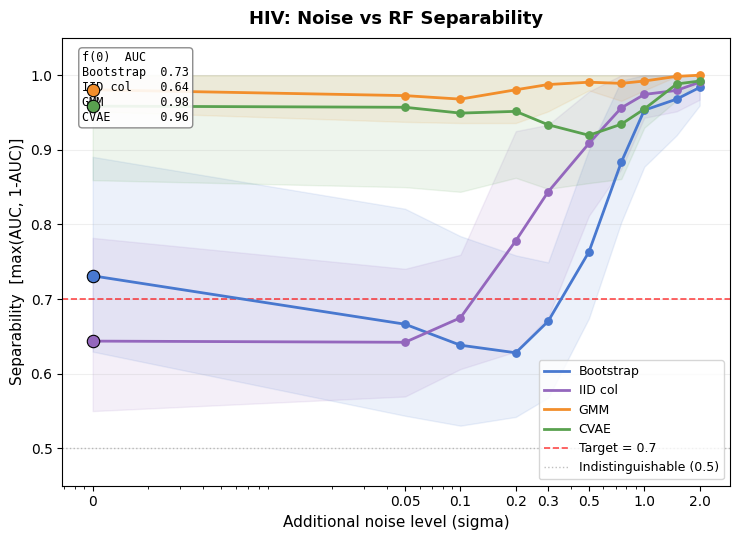

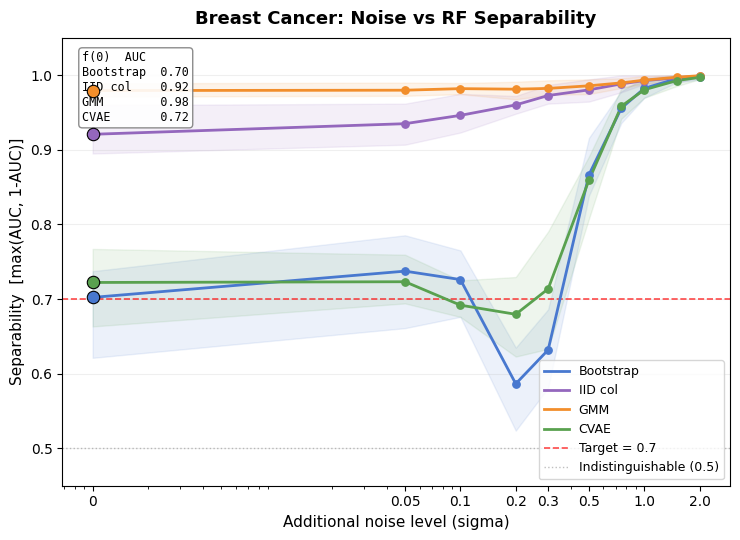

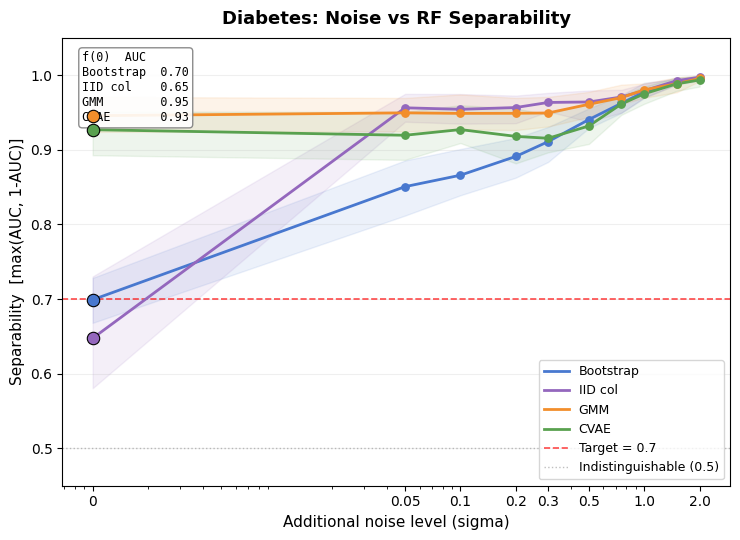

In [5]:
# ── Section 7 plot: all four generators overlaid ─────────────────────────────
# Fix: use max(AUC, 1-AUC) so separability is symmetric around 0.5.
# AUC=0.27 and AUC=0.73 both mean "separability = 0.23 from coin-flip".
# Without this, bootstrap appears to start low — but it's actually highly
# distinguishable, just with inverted label predictions.

EPS = 1e-3   # stand-in for sigma=0 on log scale

def corrected_auc(raw_auc):
    """Absolute separability: 0.5 = indistinguishable, 1.0 = perfectly separable."""
    return max(raw_auc, 1.0 - raw_auc)

METHODS = [
    ("Bootstrap", "bootstrap", METHOD_COLORS["bootstrap"]),
    ("IID col",   "iid",       METHOD_COLORS["iid"]),
    ("GMM",       "gmm",       METHOD_COLORS["gmm"]),
    ("CVAE",      "cvae",      METHOD_COLORS["cvae"]),
]

PRETTY = {"HIV": "HIV", "Breast Cancer": "Breast Cancer", "Diabetes": "Diabetes"}

for ds_name in LOADERS:
    fig, ax = plt.subplots(figsize=(7.5, 5.5))
    plot_sigmas = np.array([s if s > 0 else EPS for s in PROBE_SIGMAS])

    f0_lines = []

    for label, key, color in METHODS:
        if key == "bootstrap":
            auc_dict = sigma_auc_data[ds_name]
        else:
            auc_dict = model_sigma_auc_data[ds_name][key]

        # apply correction: max(auc, 1-auc) per individual run
        corrected = {s: [corrected_auc(a) for a in auc_dict[s]] for s in PROBE_SIGMAS}

        means = [np.mean(corrected[s]) for s in PROBE_SIGMAS]
        q10   = [np.percentile(corrected[s], 10) for s in PROBE_SIGMAS]
        q90   = [np.percentile(corrected[s], 90) for s in PROBE_SIGMAS]

        ax.fill_between(plot_sigmas, q10, q90, alpha=0.10, color=color)
        ax.plot(plot_sigmas, means, color=color, linewidth=2.0, label=label, zorder=3)
        ax.scatter(plot_sigmas, means, color=color, s=28, zorder=4)
        ax.scatter([EPS], [means[0]], s=80, color=color,
                   edgecolors="black", linewidths=0.8, zorder=6)

        f0_lines.append(f"{label:<10s} {means[0]:.2f}")

    # target separability
    ax.axhline(TARGET_AUC, ls="--", color="red", lw=1.2, alpha=0.7,
               label=f"Target = {TARGET_AUC}")
    # true indistinguishability
    ax.axhline(0.5, ls=":", color="grey", lw=1.0, alpha=0.5,
               label="Indistinguishable (0.5)")

    f0_text = "f(0)  AUC\n" + "\n".join(f0_lines)
    ax.text(0.03, 0.97, f0_text, transform=ax.transAxes,
            ha="left", va="top", fontsize=8.5, family="monospace",
            bbox=dict(boxstyle="round,pad=0.3", facecolor="white",
                      edgecolor="grey", alpha=0.90))

    ax.set_title(f"{PRETTY.get(ds_name, ds_name)}: Noise vs RF Separability",
                 fontsize=13, fontweight="bold", pad=10)
    ax.set_xlabel("Additional noise level (sigma)", fontsize=11)
    ax.set_ylabel("Separability  [max(AUC, 1-AUC)]", fontsize=11)

    ax.set_xscale("log")
    ax.set_xticks([EPS, 0.05, 0.1, 0.2, 0.3, 0.5, 1.0, 2.0])
    ax.set_xticklabels(["0", "0.05", "0.1", "0.2", "0.3", "0.5", "1.0", "2.0"])
    ax.set_ylim(0.45, 1.05)
    ax.grid(axis="y", alpha=0.20)
    ax.legend(fontsize=9, loc="lower right")

    plt.tight_layout()
    plt.show()


### Interpretation

*[What shape does the curve take? Is there a sharp threshold or a gradual rise?  
Do the dotted verticals (hack_sigma) consistently land near the target AUC horizontal?  
What does it mean if the binary search sigma falls far left or far right on the curve?]*

> **Can indistinguishability be artificially achieved?**

---
## Section 8 — Privacy-Utility Tradeoff

For each generator, we ask:
1. **Privacy** — What is the best (lowest) separability achievable across all noise levels?
2. **Utility** — What happens to downstream model performance (TSTR F1) at that noise level?
3. **Tradeoff** — Does hiding synthetic data destroy its usefulness?

Uses the sigma sweep data from Section 7, plus TSTR F1 computed at each σ.

In [6]:
# ── Section 8: privacy-utility tradeoff ───────────────────────────────────────
# For each dataset x model x sigma, compute separability AND utility (TSTR F1).
# Then find the "best" sigma = lowest separability, and report the utility cost.

from rfhack.models.bootstrap import sample_bootstrap
from rfhack.models.iid_columnwise import sample_columnwise
from rfhack.models.gmm import sample_gmm
from rfhack.models.cvae import train_cvae_on_arrays, sample_cvae_dataset
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import f1_score

def corrected_auc(raw_auc):
    return max(raw_auc, 1.0 - raw_auc)

CVAE_EPOCHS_S8 = 200
TRADEOFF_SIGMAS = [0.0, 0.05, 0.1, 0.2, 0.3, 0.5, 0.75, 1.0]
N_REP = 5   # repeats per sigma for stability

tradeoff_rows = []

for ds_name, loader in LOADERS.items():
    data = loader()
    X, y = data["X"], data["y"]

    for frac in FRACTIONS:
        n0 = max(2, int((y == 0).sum() * frac))
        n1 = max(2, int((y == 1).sum() * frac))
        X_sub, y_sub, _ = stratified_subsample(X, y, n0=n0, n1=n1, seed=SEED)

        stds = X_sub.astype(np.float64).std(axis=0)
        stds = np.where(stds == 0, 1.0, stds)

        # train CVAE once per dataset x frac
        cvae_state = train_cvae_on_arrays(
            X_sub, y_sub, seed=SEED, epochs=CVAE_EPOCHS_S8, batch_size=32
        )

        generators = {
            "Bootstrap": lambda seed_i: sample_bootstrap(X_sub, y_sub, n0, n1, seed=seed_i),
            "IID col":   lambda seed_i: sample_columnwise(X_sub, y_sub, n0, n1, seed=seed_i),
            "GMM":       lambda seed_i: sample_gmm(X_sub, y_sub, n0, n1, seed=seed_i),
            "CVAE":      lambda seed_i: sample_cvae_dataset(cvae_state, n0, n1, seed=seed_i),
        }

        for model_name, gen_fn in generators.items():
            best_sep   = 1.0
            best_sigma = 0.0
            best_tstr  = 0.0
            f0_sep     = None
            f0_tstr    = None

            for sigma in TRADEOFF_SIGMAS:
                seps  = []
                tstrs = []

                for rep in range(N_REP):
                    rep_seed = SEED + rep
                    X_syn, y_syn = gen_fn(rep_seed)
                    X_syn = X_syn.astype(np.float64)

                    # add noise
                    if sigma > 0:
                        rng = np.random.default_rng(rep_seed + 500)
                        X_syn = X_syn + rng.standard_normal(X_syn.shape) * stds * sigma

                    # separability: RF real-vs-synthetic
                    feat_cols = [f"f{i}" for i in range(X_sub.shape[1])]
                    real_df = pd.DataFrame(X_sub.astype(np.float64), columns=feat_cols)
                    real_df["target"] = 1
                    syn_df = pd.DataFrame(X_syn, columns=feat_cols)
                    syn_df["target"] = 0
                    combined = pd.concat([real_df, syn_df], ignore_index=True)
                    avg, _, _ = RFWrapper.from_combined(combined)
                    seps.append(corrected_auc(avg))

                    # utility: TSTR F1
                    X_syn_f32 = X_syn.astype(np.float32)
                    rf = RandomForestClassifier(n_estimators=100, random_state=rep_seed)
                    rf.fit(X_syn_f32, y_syn)
                    tstr = f1_score(y_sub, rf.predict(X_sub), average="binary", zero_division=0)
                    tstrs.append(tstr)

                mean_sep  = np.mean(seps)
                mean_tstr = np.mean(tstrs)

                if sigma == 0.0:
                    f0_sep  = mean_sep
                    f0_tstr = mean_tstr

                if mean_sep < best_sep:
                    best_sep   = mean_sep
                    best_sigma = sigma
                    best_tstr  = mean_tstr

            tradeoff_rows.append({
                "Dataset":       ds_name,
                "Frac":          frac,
                "Model":         model_name,
                "f(0) Sep":      f0_sep,
                "f(0) TSTR F1":  f0_tstr,
                "Best Sep":      best_sep,
                "Best sigma":    best_sigma,
                "Best TSTR F1":  best_tstr,
                "Utility Cost":  f0_tstr - best_tstr,
            })
            print(f"{ds_name:<15} frac={frac}  {model_name:<10}  "
                  f"f(0)={f0_sep:.3f}/{f0_tstr:.3f}  "
                  f"best={best_sep:.3f}@s={best_sigma:.2f}  TSTR={best_tstr:.3f}")

summary = pd.DataFrame(tradeoff_rows).set_index(["Dataset", "Frac", "Model"])
print(f"\n{len(summary)} rows computed.")
summary.round(4)


c:\Users\tonyt\Desktop\rfhack\.venv\Lib\site-packages\sklearn\preprocessing\_label.py:120: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)


Epoch  50 | val loss=66.0324 recon=65.2859 kl=1.4931
Epoch 100 | val loss=62.0239 recon=60.2843 kl=3.4790
Epoch 150 | val loss=59.5011 recon=57.3479 kl=4.3064
Epoch 200 | val loss=55.2172 recon=52.3763 kl=5.6818
HIV             frac=0.2  Bootstrap   f(0)=0.685/1.000  best=0.558@s=0.30  TSTR=0.986
HIV             frac=0.2  IID col     f(0)=0.739/1.000  best=0.538@s=0.20  TSTR=0.993
HIV             frac=0.2  GMM         f(0)=0.813/0.949  best=0.813@s=0.00  TSTR=0.949
HIV             frac=0.2  CVAE        f(0)=0.904/0.959  best=0.783@s=0.50  TSTR=0.941
Epoch  50 | val loss=72.9056 recon=70.1432 kl=5.5246
Epoch 100 | val loss=68.6422 recon=65.2822 kl=6.7200
Epoch 150 | val loss=61.7664 recon=57.5322 kl=8.4684
Epoch 200 | val loss=71.1161 recon=67.0447 kl=8.1428
HIV             frac=0.3  Bootstrap   f(0)=0.712/0.995  best=0.550@s=0.20  TSTR=0.976
HIV             frac=0.3  IID col     f(0)=0.647/0.995  best=0.529@s=0.05  TSTR=0.995
HIV             frac=0.3  GMM         f(0)=0.958/0.985  best

f(0) Sep  f(0) TSTR F1  Best Sep  Best sigma  \
Dataset       Frac Model                                                     
HIV           0.2  Bootstrap    0.6850        1.0000    0.5577        0.30   
                   IID col      0.7390        1.0000    0.5377        0.20   
                   GMM          0.8133        0.9494    0.8133        0.00   
                   CVAE         0.9043        0.9593    0.7827        0.50   
              0.3  Bootstrap    0.7119        0.9951    0.5505        0.20   
                   IID col      0.6473        0.9949    0.5289        0.05   
                   GMM          0.9575        0.9854    0.9575        0.00   
                   CVAE         0.9186        0.8821    0.8977        0.50   
              0.4  Bootstrap    0.6998        0.9814    0.5579        0.10   
                   IID col      0.5695        0.9926    0.5695        0.00   
                   GMM          0.9936        0.9856    0.9936        0.00   
                   CVAE         0.9234        0.9509    0.9116        0.20   
              0.5  Bootstrap    0.7453        0.9943    0.5392        0.10   
                   IID col      0.6073        0.9970    0.6073        0.00   
                   GMM          0.9948        0.9881    0.9948        0.00   
                   CVAE         0.9731        0.9502    0.9645        0.20   
Breast Cancer 0.2  Bootstrap    0.6934        0.9773    0.5228        0.30   
                   IID col      0.8412        0.9545    0.8412        0.00   
                   GMM          0.9555        0.9540    0.9555        0.00   
                   CVAE         0.7244        0.9494    0.6767        0.30   
              0.3  Bootstrap    0.7080        0.9821    0.6055        0.30   
                   IID col      0.9387        0.9538    0.9387        0.00   
                   GMM          0.9797        0.9629    0.9794        0.10   
                   CVAE         0.6953        0.9679    0.6652        0.20   
              0.4  Bootstrap    0.7047        0.9833    0.5273        0.20   
                   IID col      0.9753        0.9695    0.9751        0.30   
                   GMM          0.9866        0.9558    0.9860        0.10   
                   CVAE         0.6956        0.9599    0.6698        0.10   
              0.5  Bootstrap    0.7060        0.9848    0.5772        0.20   
                   IID col      0.9900        0.9621    0.9874        0.30   
                   GMM          0.9878        0.9629    0.9878        0.05   
                   CVAE         0.7960        0.9745    0.7574        0.20   
Diabetes      0.2  Bootstrap    0.7238        0.8552    0.7238        0.00   
                   IID col      0.5886        0.7081    0.5886        0.00   
                   GMM          0.9212        0.6757    0.9202        0.05   
                   CVAE         0.9034        0.6910    0.8781        0.30   
              0.3  Bootstrap    0.7006        0.8363    0.7006        0.00   
                   IID col      0.6535        0.6682    0.6535        0.00   
                   GMM          0.9438        0.5867    0.9429        0.10   
                   CVAE         0.9512        0.6810    0.9280        0.30   
              0.4  Bootstrap    0.7095        0.8580    0.7095        0.00   
                   IID col      0.6725        0.7111    0.6725        0.00   
                   GMM          0.9518        0.6368    0.9518        0.00   
                   CVAE         0.9427        0.6773    0.9210        0.30   
              0.5  Bootstrap    0.7022        0.8441    0.7022        0.00   
                   IID col      0.7120        0.6478    0.7120        0.00   
                   GMM          0.9585        0.6025    0.9575        0.10   
                   CVAE         0.9480        0.6355    0.9286        0.30   

                              Best TSTR F1  Utility Cost  
Dataset       Frac Model                                  
HIV        

In [7]:
# ── styled display ─────────────────────────────────────────────────────────────

def _color_sep(val):
    norm = float(np.clip((val - 0.5) / 0.5, 0, 1))
    r = int(215 * norm + 26  * (1 - norm))
    g = int(48  * norm + 152 * (1 - norm))
    b = int(39  * norm + 80  * (1 - norm))
    return f"color: rgb({r},{g},{b})"

def _color_cost(val):
    color = "#1a9850" if val < 0.05 else "#d73027"
    return f"color: {color}"

styled = (
    summary.style
    .format({
        "f(0) Sep":     "{:.3f}",
        "f(0) TSTR F1": "{:.3f}",
        "Best Sep":     "{:.3f}",
        "Best sigma":   "{:.2f}",
        "Best TSTR F1": "{:.3f}",
        "Utility Cost": "{:+.3f}",
    })
    .map(_color_sep, subset=["f(0) Sep", "Best Sep"])
    .map(_color_cost, subset=["Utility Cost"])
    .set_table_styles([
        {"selector": "th", "props": [("font-size", "11px"), ("text-align", "center")]},
        {"selector": "td", "props": [("font-size", "11px"), ("text-align", "center")]},
    ])
    .set_caption("Table 1. Privacy-utility tradeoff: best achievable separability and its utility cost.")
)

styled


In [8]:
# ── compact pivot: mean per (Dataset, Model) across fractions ─────────────────
pivot = (
    summary.reset_index()
    .groupby(["Dataset", "Model"])[["f(0) Sep", "Best Sep", "Best TSTR F1", "Utility Cost"]]
    .mean()
    .round(4)
)
pivot


f(0) Sep  Best Sep  Best TSTR F1  Utility Cost
Dataset       Model                                                    
Breast Cancer Bootstrap    0.7030    0.5582        0.9669        0.0150
              CVAE         0.7278    0.6923        0.9602        0.0027
              GMM          0.9774    0.9772        0.9587        0.0002
              IID col      0.9363    0.9356        0.9533        0.0067
Diabetes      Bootstrap    0.7090    0.7090        0.8484        0.0000
              CVAE         0.9363    0.9139        0.6501        0.0210
              GMM          0.9438    0.9431        0.6274       -0.0020
              IID col      0.6566    0.6566        0.6838        0.0000
HIV           Bootstrap    0.7105    0.5513        0.9838        0.0089
              CVAE         0.9298    0.8891        0.9365       -0.0009
              GMM          0.9398    0.9398        0.9771        0.0000
              IID col      0.6408    0.5608        0.9943        0.0019

### Interpretation

The table reveals the privacy-utility tradeoff:

- **Bootstrap** starts with low separability (near 0.5) and can reach the target.
  Adding noise costs little utility because the copies are already structurally correct.
- **GMM / CVAE** start with high separability (~0.95) and noise cannot fix this.
  Their detectability is structural: wrong correlations, wrong tails, wrong feature interactions.
  Adding noise only degrades utility without improving privacy.

**Conclusion:** Noise-based indistinguishability only works for generators that are already
structurally close to the real data. For model-based generators, detectability is a distribution
problem, not a perturbation problem.

---
## Section 9 — Many-to-One AUC: DRSU Profile

**Claim:** AUC alone is insufficient to characterise synthetic data quality. Two synthetic
datasets can share the **same RF separability** while having **completely different**
profiles along the four pillars of synthetic quality:

- **D**istribution — Do feature marginals match? (KL divergence)
- **R**ealism — Do synthetic samples sit near real ones? (NN distance)
- **S**tructure — Are inter-feature correlations preserved? (|Δ corr|)
- **U**tility — Does training on synthetic transfer to real? (TSTR F1)

**Demo:** We focus on bootstrap because it is the only generator whose separability
genuinely *moves* with σ (it has a U-shape). We pick two σ values — one on the
"too-similar" side and one on the "too-noisy" side — that yield the **same separability**,
then compute their DRSU profiles.

In [9]:
# ── Section 9: find two bootstrap sigmas with matching separability ──────────
from rfhack.models.bootstrap import sample_bootstrap
from rfhack.core.metrics import (
    kld_per_feature, correlation_diff, tstr_f1
)
from sklearn.neighbors import NearestNeighbors

DEMO_DATASET = "HIV"
DEMO_FRAC    = 0.3
N_REP_S9     = 8

def corrected_auc(a):
    return max(a, 1.0 - a)

def nn_distances_inline(X_real, X_syn):
    """Mean nearest-neighbour distance from each syn point to its closest real point."""
    nn = NearestNeighbors(n_neighbors=1).fit(X_real)
    d, _ = nn.kneighbors(X_syn)
    return float(d.mean())

# Build the demo subsample
data = LOADERS[DEMO_DATASET]()
X, y = data["X"], data["y"]
n0 = max(2, int((y == 0).sum() * DEMO_FRAC))
n1 = max(2, int((y == 1).sum() * DEMO_FRAC))
X_sub, y_sub, _ = stratified_subsample(X, y, n0=n0, n1=n1, seed=SEED)

stds = X_sub.astype(np.float64).std(axis=0)
stds = np.where(stds == 0, 1.0, stds)
feat_cols = [f"f{i}" for i in range(X_sub.shape[1])]

def bootstrap_sep_at(sigma, n_rep=N_REP_S9):
    seps = []
    for r in range(n_rep):
        rep_seed = SEED + r
        X_b, y_b = sample_bootstrap(X_sub, y_sub, n0, n1, seed=rep_seed)
        rng = np.random.default_rng(rep_seed + 700)
        X_b = X_b.astype(np.float64) + rng.standard_normal(X_b.shape) * stds * sigma

        real_df = pd.DataFrame(X_sub.astype(np.float64), columns=feat_cols)
        real_df["target"] = 1
        syn_df = pd.DataFrame(X_b, columns=feat_cols)
        syn_df["target"] = 0
        combined = pd.concat([real_df, syn_df], ignore_index=True)
        avg, _, _ = RFWrapper.from_combined(combined)
        seps.append(corrected_auc(avg))
    return float(np.mean(seps))

# Fine sweep across the U-curve
FINE_SIGMAS = np.round(np.linspace(0.0, 0.6, 25), 4)
print(f"Sweeping bootstrap sigma on {DEMO_DATASET} (frac={DEMO_FRAC})...")
sep_curve = {s: bootstrap_sep_at(s) for s in FINE_SIGMAS}
for s, sep in sep_curve.items():
    print(f"  sigma={s:.3f}  sep={sep:.3f}")

# Find the bottom of the U
min_sigma = min(sep_curve, key=sep_curve.get)
min_sep   = sep_curve[min_sigma]
print(f"\nU-curve minimum: sigma={min_sigma:.3f}  sep={min_sep:.3f}")

# Pick a target separability above the floor; find two sigmas with similar sep
# on opposite sides of the minimum
target_sep = min_sep + 0.06   # comfortably above floor

left  = [(s, sep) for s, sep in sep_curve.items() if s < min_sigma]
right = [(s, sep) for s, sep in sep_curve.items() if s > min_sigma]

if left and right:
    sigma_low,  _ = min(left,  key=lambda kv: abs(kv[1] - target_sep))
    sigma_high, _ = min(right, key=lambda kv: abs(kv[1] - target_sep))
else:
    # fallback: pick the two extremes
    sigma_low  = FINE_SIGMAS[0]
    sigma_high = FINE_SIGMAS[-1]

print(f"\nMatched pair (target sep \u2248 {target_sep:.3f}):")
print(f"  LOW   sigma={sigma_low:.3f}  sep={sep_curve[sigma_low]:.3f}")
print(f"  HIGH  sigma={sigma_high:.3f}  sep={sep_curve[sigma_high]:.3f}")


c:\Users\tonyt\Desktop\rfhack\.venv\Lib\site-packages\sklearn\preprocessing\_label.py:120: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)


Sweeping bootstrap sigma on HIV (frac=0.3)...
  sigma=0.000  sep=0.750
  sigma=0.025  sep=0.692
  sigma=0.050  sep=0.679
  sigma=0.075  sep=0.657
  sigma=0.100  sep=0.636
  sigma=0.125  sep=0.610
  sigma=0.150  sep=0.585
  sigma=0.175  sep=0.562
  sigma=0.200  sep=0.548
  sigma=0.225  sep=0.547
  sigma=0.250  sep=0.565
  sigma=0.275  sep=0.603
  sigma=0.300  sep=0.632
  sigma=0.325  sep=0.653
  sigma=0.350  sep=0.674
  sigma=0.375  sep=0.702
  sigma=0.400  sep=0.738
  sigma=0.425  sep=0.760
  sigma=0.450  sep=0.785
  sigma=0.475  sep=0.808
  sigma=0.500  sep=0.823
  sigma=0.525  sep=0.845
  sigma=0.550  sep=0.858
  sigma=0.575  sep=0.868
  sigma=0.600  sep=0.880

U-curve minimum: sigma=0.225  sep=0.547

Matched pair (target sep ≈ 0.607):
  LOW   sigma=0.125  sep=0.610
  HIGH  sigma=0.275  sep=0.603


In [10]:
# ── Compute the DRSU profile for each chosen sigma ───────────────────────────

def drsu_profile(sigma, n_rep=N_REP_S9):
    klds, corrs, nns, tstrs, seps = [], [], [], [], []
    for r in range(n_rep):
        rep_seed = SEED + r
        X_b, y_b = sample_bootstrap(X_sub, y_sub, n0, n1, seed=rep_seed)
        rng = np.random.default_rng(rep_seed + 700)
        X_b = X_b.astype(np.float64) + rng.standard_normal(X_b.shape) * stds * sigma

        # Distribution
        klds.append(kld_per_feature(X_sub, X_b)["kld_mean"])
        # Structure
        corrs.append(correlation_diff(X_sub, X_b)["corr_mean_abs_diff"])
        # Realism
        nns.append(nn_distances_inline(X_sub, X_b))
        # Utility
        u = tstr_f1(X_sub, y_sub, X_b.astype(np.float32), y_b, seed=rep_seed)
        tstrs.append(u["tstr_f1"])

        # Separability (re-check)
        real_df = pd.DataFrame(X_sub.astype(np.float64), columns=feat_cols)
        real_df["target"] = 1
        syn_df = pd.DataFrame(X_b, columns=feat_cols)
        syn_df["target"] = 0
        combined = pd.concat([real_df, syn_df], ignore_index=True)
        avg, _, _ = RFWrapper.from_combined(combined)
        seps.append(corrected_auc(avg))

    return {
        "Separability":   np.mean(seps),
        "KLD (D)":        np.mean(klds),
        "|\u0394 Corr| (S)": np.mean(corrs),
        "NN dist (R)":    np.mean(nns),
        "TSTR F1 (U)":    np.mean(tstrs),
    }

profile_low  = drsu_profile(sigma_low)
profile_high = drsu_profile(sigma_high)

profile_df = pd.DataFrame({
    f"\u03c3 = {sigma_low:.3f} (low)":  profile_low,
    f"\u03c3 = {sigma_high:.3f} (high)": profile_high,
}).round(4)

print(profile_df)
profile_df


              σ = 0.125 (low)  σ = 0.275 (high)
Separability           0.6098            0.6032
KLD (D)                3.7390            4.7137
|Δ Corr| (S)           0.1213            0.1291
NN dist (R)          494.7901         1088.2483
TSTR F1 (U)            0.9848            0.9730


,σ = 0.125 (low),σ = 0.275 (high)
Separability,0.6098,0.6032
KLD (D),3.7390,4.7137
|Δ Corr| (S),0.1213,0.1291
NN dist (R),494.7901,1088.2483
TSTR F1 (U),0.9848,0.9730


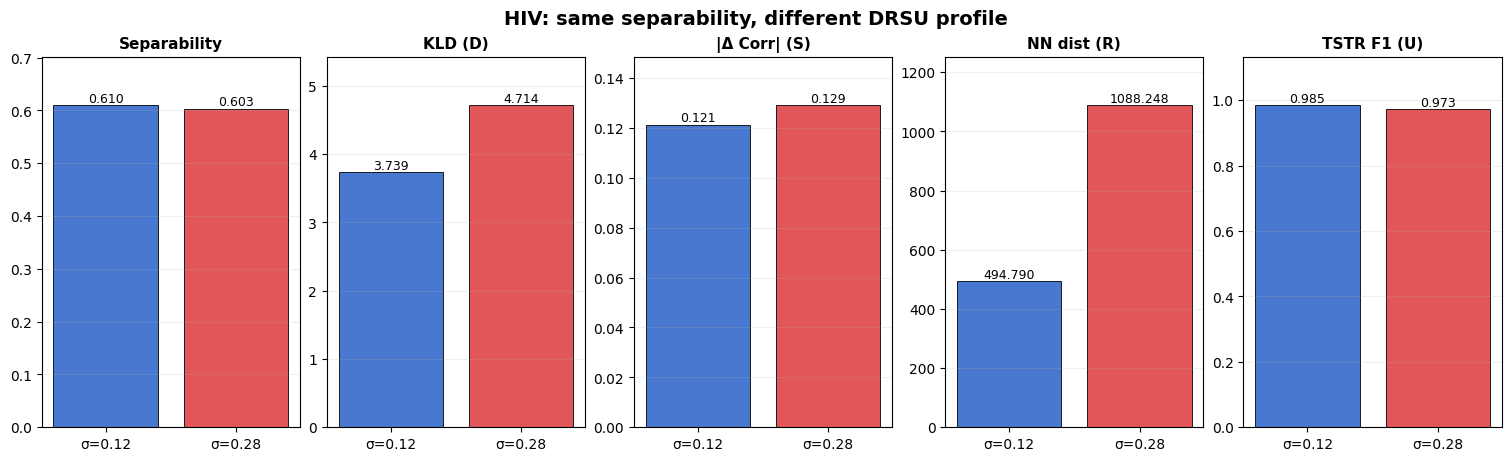

In [11]:
# ── Side-by-side DRSU comparison ─────────────────────────────────────────────
# Two bars per metric: low-sigma vs high-sigma. Same separability,
# but the four pillars tell a different story.

metrics_in_order = ["Separability", "KLD (D)", "|\u0394 Corr| (S)",
                    "NN dist (R)", "TSTR F1 (U)"]
labels_low  = f"\u03c3 = {sigma_low:.3f} (too similar)"
labels_high = f"\u03c3 = {sigma_high:.3f} (too noisy)"

vals_low  = [profile_low[m]  for m in metrics_in_order]
vals_high = [profile_high[m] for m in metrics_in_order]

fig, axes = plt.subplots(1, len(metrics_in_order), figsize=(15, 4.5),
                         constrained_layout=True)

bar_colors = ["#4878CF", "#E15759"]   # low=blue, high=red
for ax, name, vlow, vhigh in zip(axes, metrics_in_order, vals_low, vals_high):
    ax.bar([0, 1], [vlow, vhigh], color=bar_colors,
           edgecolor="black", linewidth=0.6)
    ax.set_xticks([0, 1])
    ax.set_xticklabels([f"\u03c3={sigma_low:.2f}", f"\u03c3={sigma_high:.2f}"],
                       fontsize=10)
    ax.set_title(name, fontsize=11, fontweight="bold")
    ax.grid(axis="y", alpha=0.20)
    # annotate values
    for x, v in zip([0, 1], [vlow, vhigh]):
        ax.text(x, v, f"{v:.3f}", ha="center", va="bottom", fontsize=9)
    pad = 0.15 * max(abs(vlow), abs(vhigh), 1e-6)
    ax.set_ylim(0, max(vlow, vhigh) + pad)

fig.suptitle(
    f"{DEMO_DATASET}: same separability, different DRSU profile",
    fontsize=14, fontweight="bold"
)
plt.show()


### Interpretation

The two columns share the same RF separability — a discriminator cannot tell them apart by
that single metric. But once you look at the four pillars:

- The **low-σ** dataset is detectable because it is **too similar** to the real data
  (KLD low, NN distance low, structure preserved, utility intact — but the RF still
  spots near-duplicates).
- The **high-σ** dataset is detectable because it is **too noisy** (KLD higher, NN
  distance larger, correlations broken, utility degraded).

**Takeaway:** AUC is many-to-one. A single number cannot summarise synthetic data quality.
The DRSU profile disentangles "detectable because too close" from "detectable because too
far," and these failure modes have very different consequences for downstream use.